# Group 51 — Multi-Architecture Training (4 models)
### EfficientNetB0 · ResNet50 · MobileNetV2 · DenseNet121 — trained on `dataset_v2`

This notebook trains **4 architectures**, one after another, using the exact
same training conventions as `Group51_Training_Local.ipynb`:
- Same `WasteDataset` class and transforms
- Same `compute_class_weight` (balanced) + `label_smoothing=0.1`
- Same 2-phase schedule: frozen head (Phase 1) → partial unfreeze fine-tune (Phase 2)
- Same `ReduceLROnPlateau` scheduler + early stopping (patience=7)
- Same checkpoint format (`primary_checkpoint.pth` per model)

Each model gets its own output folder: `model_<architecture>/`

At the end, all 4 models are evaluated on the same `dataset_v2/test` set and
a comparison table + charts are produced (feeds into a separate comparison
notebook, or you can just read the summary at the bottom of this one).


## Cell 1 — Check environment and MPS

In [1]:
import sys, os, platform
import torch
import torchvision

print(f'Python       : {sys.version}')
print(f'Platform     : {platform.platform()}')
print(f'PyTorch      : {torch.__version__}')
print(f'Torchvision  : {torchvision.__version__}')
print()

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: MPS (Apple Silicon GPU) — training will be accelerated')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Device: CUDA GPU — {torch.cuda.get_device_name(0)}')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU only — training will be slow, consider reducing epochs')

print(f'\nUsing device: {DEVICE}')

if DEVICE.type == 'mps':
    try:
        t = torch.zeros(1, device=DEVICE)
        print('MPS tensor test passed.')
    except Exception as e:
        print(f'MPS test failed: {e}. Falling back to CPU.')
        DEVICE = torch.device('cpu')


Python       : 3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
Platform     : macOS-26.5.1-arm64-arm-64bit
PyTorch      : 2.11.0
Torchvision  : 0.26.0

Device: MPS (Apple Silicon GPU) — training will be accelerated

Using device: mps
MPS tensor test passed.


## Cell 2 — Config (edit paths and hyperparameters here)

In [2]:
import os
from pathlib import Path

# ── PATHS — resolved automatically, override with the PIPELINE_ROOT env var ─
def _resolve_pipeline_root(marker="model_and_data_pipeline"):
    """Locate the model_and_data_pipeline directory without hardcoding a
    machine-specific path. Checks PIPELINE_ROOT env var first, then walks
    up from the current working directory (Jupyter's default cwd is the
    notebook's own directory)."""
    env = os.environ.get("PIPELINE_ROOT")
    if env:
        return Path(env)
    cwd = Path.cwd()
    if cwd.name == marker:
        return cwd
    for parent in [cwd, *cwd.parents]:
        candidate = parent / marker
        if candidate.exists():
            return candidate
    return cwd  # last resort: assume the notebook already runs from here
BASE          = _resolve_pipeline_root()
DATASET_PATH  = BASE / 'dataset_v2'
TRAIN_DIR     = DATASET_PATH / 'train'
VAL_DIR       = DATASET_PATH / 'val'
TEST_DIR      = DATASET_PATH / 'test'

# Each architecture gets its own output folder: model_<architecture_name>
ARCHITECTURES = ['efficientnet_b0', 'resnet50', 'mobilenet_v2', 'densenet121']
MODEL_DIRS = {arch: BASE / f'model_{arch}' for arch in ARCHITECTURES}
for d in MODEL_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

COMPARISON_DIR = BASE / 'comparison_4arch'
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

# ── HYPERPARAMETERS — identical to Group51_Training_Local.ipynb, same for ──
# ── every architecture so the comparison is fair ────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS_PHASE1   = 10
EPOCHS_PHASE2   = 20
LR_PHASE1       = 1e-3
LR_PHASE2       = 1e-5
UNFREEZE_LAYERS = 30       # how many trailing backbone param tensors to unfreeze in phase 2
DROPOUT_RATE    = 0.4
LABEL_SMOOTHING = 0.1
NUM_WORKERS     = 0
PATIENCE        = 7

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── VALIDATE PATHS ────────────────────────────────────────────────────────────
missing = [d for d in [TRAIN_DIR, VAL_DIR, TEST_DIR] if not d.exists()]
if missing:
    raise FileNotFoundError(
        'These dataset folders are missing:\n' +
        '\n'.join(f'  {d}' for d in missing) +
        '\nUpdate DATASET_PATH in this cell.'
    )

print('Config loaded.')
print(f'  Dataset    : {DATASET_PATH}')
print(f'  Device     : {DEVICE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Phase 1    : {EPOCHS_PHASE1} epochs @ lr={LR_PHASE1}')
print(f'  Phase 2    : {EPOCHS_PHASE2} epochs @ lr={LR_PHASE2}')
print(f'  Architectures: {ARCHITECTURES}')
for arch, d in MODEL_DIRS.items():
    print(f'    {arch:<16} -> {d}')


Config loaded.
  Dataset    : /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/dataset_v2
  Device     : mps
  Batch size : 32
  Phase 1    : 10 epochs @ lr=0.001
  Phase 2    : 20 epochs @ lr=1e-05
  Architectures: ['efficientnet_b0', 'resnet50', 'mobilenet_v2', 'densenet121']
    efficientnet_b0  -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_efficientnet_b0
    resnet50         -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_resnet50
    mobilenet_v2     -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_mobilenet_v2
    densenet121      -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_densenet121


## Cell 3 — Inspect dataset

In [3]:
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images(split_dir):
    counts = {}
    for cls_dir in sorted(Path(split_dir).iterdir()):
        if cls_dir.is_dir():
            counts[cls_dir.name] = sum(
                1 for f in cls_dir.iterdir() if f.suffix.lower() in VALID_EXT
            )
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

CLASS_NAMES = sorted(train_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}

import json
# Same class_indices.json saved into every model's folder for consistency
for d in MODEL_DIRS.values():
    with open(d / 'class_indices.json', 'w') as f:
        json.dump(CLASS_TO_IDX, f, indent=2)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print()
print(f'{"Class":<16} {"Train":>8} {"Val":>8} {"Test":>8} {"Total":>9}')
print('─' * 53)
grand = 0
for cls in CLASS_NAMES:
    tr  = train_counts.get(cls, 0)
    va  = val_counts.get(cls, 0)
    te  = test_counts.get(cls, 0)
    tot = tr + va + te
    grand += tot
    flag = '  <-- augmentation recommended' if tr < 1000 else ''
    print(f'{cls:<16} {tr:>8,} {va:>8,} {te:>8,} {tot:>9,}{flag}')
print('─' * 53)
print(f'{"TOTAL":<16} {sum(train_counts.values()):>8,} '
      f'{sum(val_counts.values()):>8,} '
      f'{sum(test_counts.values()):>8,} {grand:>9,}')


Classes (8): ['e-waste', 'general_trash', 'glass', 'hazardous', 'metal', 'organic', 'paper', 'plastic']

Class               Train      Val     Test     Total
─────────────────────────────────────────────────────
e-waste             2,209      473      474     3,156
general_trash       6,320    1,354    1,354     9,028
glass               2,888      619      619     4,126
hazardous           1,500      147      146     1,793
metal               1,831      392      392     2,615
organic            16,288    3,490    3,490    23,268
paper               5,286    1,133    1,133     7,552
plastic            11,075    2,374    2,374    15,823
─────────────────────────────────────────────────────
TOTAL              47,397    9,982    9,982    67,361


## Cell 4 — Build PyTorch dataset and dataloaders (shared across all architectures)

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class WasteDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.samples = []
        self.transform = transform
        root_dir = Path(root_dir)
        for cls_name, idx in class_to_idx.items():
            cls_dir = root_dir / cls_name
            if not cls_dir.exists():
                continue
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in VALID_EXT:
                    self.samples.append((str(img_path), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = WasteDataset(TRAIN_DIR, CLASS_TO_IDX, transform=train_transform)
val_dataset   = WasteDataset(VAL_DIR,   CLASS_TO_IDX, transform=val_transform)
test_dataset  = WasteDataset(TEST_DIR,  CLASS_TO_IDX, transform=val_transform)

# ── CLASS WEIGHTS — same method as Group51_Training_Local.ipynb ────────────
from sklearn.utils.class_weight import compute_class_weight

all_labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=all_labels
)
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print('Class weights (higher = rarer, gets more attention):')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<16} {class_weights[i]:.3f}')

pin = (DEVICE.type == 'cuda')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=pin)

print(f'\nTrain   : {len(train_dataset):,} images, {len(train_loader)} batches')
print(f'Val     : {len(val_dataset):,} images, {len(val_loader)} batches')
print(f'Test    : {len(test_dataset):,} images, {len(test_loader)} batches')


Class weights (higher = rarer, gets more attention):
  e-waste          2.682
  general_trash    0.937
  glass            2.051
  hazardous        3.950
  metal            3.236
  organic          0.364
  paper            1.121
  plastic          0.535

Train   : 47,397 images, 1482 batches
Val     : 9,982 images, 312 batches
Test    : 9,982 images, 312 batches


## Cell 5 — Model factory

Builds any of the 4 architectures with an equivalent classifier head to your
original `build_primary_model()`: `Dropout → Linear(256) → BatchNorm1d → ReLU
→ Dropout → Linear(num_classes)`. Each function returns `(model, backbone_module)`
so Phase 2 unfreezing logic can stay generic across architectures.


In [5]:
import torch.nn as nn
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    resnet50,        ResNet50_Weights,
    mobilenet_v2,    MobileNet_V2_Weights,
    densenet121,     DenseNet121_Weights,
)

def make_head(in_features, num_classes, dropout_rate=0.4):
    """Same head structure as Group51_Training_Local.ipynb's build_primary_model."""
    return nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate / 2),
        nn.Linear(256, num_classes)
    )


def build_model(arch_name, num_classes, dropout_rate=0.4):
    """
    Returns (model, backbone_module, head_module).
    backbone_module is what gets frozen in Phase 1 and partially unfrozen in
    Phase 2 (mirrors primary_model.features in the original notebook).
    """
    if arch_name == 'efficientnet_b0':
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f = model.classifier[1].in_features
        model.classifier = make_head(in_f, num_classes, dropout_rate)
        backbone = model.features
        head = model.classifier

    elif arch_name == 'resnet50':
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        in_f = model.fc.in_features
        model.fc = make_head(in_f, num_classes, dropout_rate)
        # backbone = everything except the final fc layer
        backbone = nn.ModuleList([m for n, m in model.named_children() if n != 'fc'])
        head = model.fc

    elif arch_name == 'mobilenet_v2':
        model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        in_f = model.classifier[1].in_features
        model.classifier = make_head(in_f, num_classes, dropout_rate)
        backbone = model.features
        head = model.classifier

    elif arch_name == 'densenet121':
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        in_f = model.classifier.in_features
        model.classifier = make_head(in_f, num_classes, dropout_rate)
        backbone = model.features
        head = model.classifier

    else:
        raise ValueError(f'Unknown architecture: {arch_name}')

    # Freeze backbone for Phase 1 (head is trainable by default — new layers)
    for param in backbone.parameters():
        param.requires_grad = False

    return model, backbone, head


print('Model factory defined.')
print('Supported: efficientnet_b0, resnet50, mobilenet_v2, densenet121')


Model factory defined.
Supported: efficientnet_b0, resnet50, mobilenet_v2, densenet121


## Cell 6 — Training helpers (identical logic to Group51_Training_Local.ipynb)

In [6]:
import time
import copy
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc='  train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, leave=False, desc='  eval'):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


def run_training(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 epochs, device, save_path, phase_name=''):
    best_val_acc   = 0.0
    best_weights   = copy.deepcopy(model.state_dict())
    patience_count = 0

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        elapsed = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        improved = '*' if val_acc > best_val_acc else ' '
        print(f'[{phase_name}] Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
              f'val loss {val_loss:.4f} acc {val_acc:.4f} | '
              f'{elapsed:.0f}s {improved}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
                break

    model.load_state_dict(best_weights)
    print(f'\nBest val accuracy [{phase_name}]: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    return history, best_val_acc


def plot_history(histories, phase_names, save_path, title='Training history'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    offset = 0
    colors = [('#2196F3', '#FF9800'), ('#4CAF50', '#F44336')]
    for i, (hist, name) in enumerate(zip(histories, phase_names)):
        n = len(hist['train_acc'])
        xs = range(offset + 1, offset + n + 1)
        c = colors[i % len(colors)]
        axes[0].plot(xs, hist['train_acc'], color=c[0], label=f'{name} train', linewidth=2)
        axes[0].plot(xs, hist['val_acc'],   color=c[1], label=f'{name} val',   linewidth=2)
        axes[1].plot(xs, hist['train_loss'], color=c[0], label=f'{name} train', linewidth=2)
        axes[1].plot(xs, hist['val_loss'],   color=c[1], label=f'{name} val',   linewidth=2)
        if i < len(histories) - 1:
            axes[0].axvline(offset + n + 0.5, color='gray', linestyle='--', alpha=0.5)
            axes[1].axvline(offset + n + 0.5, color='gray', linestyle='--', alpha=0.5)
        offset += n

    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_title('Loss');      axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss');     axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved training history plot -> {save_path}')

print('Training helpers defined.')


Training helpers defined.


## Cell 7 — Train all 4 architectures

Loops through each architecture, running the exact same Phase 1 (frozen
backbone) → Phase 2 (partial unfreeze, fine-tune) schedule, then evaluates on
the test set and saves `primary_checkpoint.pth` into that model's own folder.



  ARCHITECTURE: efficientnet_b0
Total params  : 4,338,052
Trainable (P1): 330,504

--- Phase 1: feature extraction (base frozen) ---


[efficientnet_b0-P1] Epoch 01/10 | train loss 1.5232 acc 0.5664 | val loss 1.8428 acc 0.6703 | 328s *


[efficientnet_b0-P1] Epoch 02/10 | train loss 1.4493 acc 0.6071 | val loss 1.8391 acc 0.6758 | 370s *


[efficientnet_b0-P1] Epoch 03/10 | train loss 1.4187 acc 0.6225 | val loss 1.8331 acc 0.6761 | 359s *


[efficientnet_b0-P1] Epoch 04/10 | train loss 1.4030 acc 0.6332 | val loss 1.8050 acc 0.6932 | 368s *


...

[efficientnet_b0-P2] Epoch 16/20 | train loss 1.1809 acc 0.7473 | val loss 1.6362 acc 0.7892 | 401s  


[efficientnet_b0-P2] Epoch 17/20 | train loss 1.1786 acc 0.7492 | val loss 1.6241 acc 0.7943 | 401s *


[efficientnet_b0-P2] Epoch 18/20 | train loss 1.1693 acc 0.7551 | val loss 1.6265 acc 0.7936 | 400s  


[efficientnet_b0-P2] Epoch 19/20 | train loss 1.1642 acc 0.7560 | val loss 1.6271 acc 0.7925 | 397s  


[efficientnet_b0-P2] Epoch 20/20 | train loss 1.1634 acc 0.7573 | val loss 1.6086 acc 0.8012 | 397s *

Best val accuracy [efficientnet_b0-P2]: 0.8012 (80.12%)


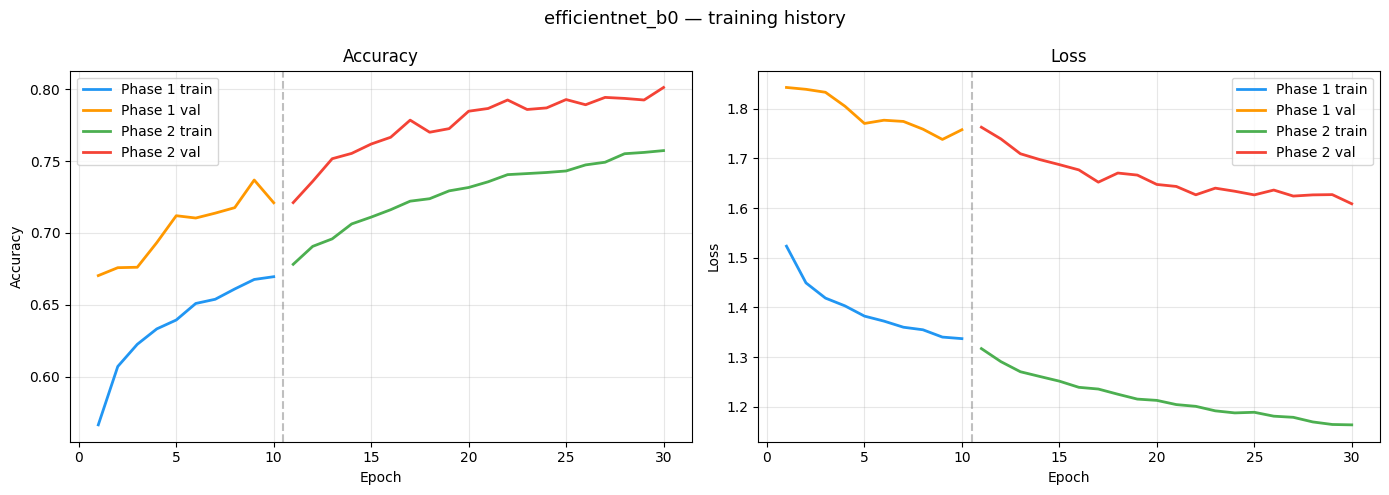

Saved training history plot -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_efficientnet_b0/training_history.png


Testing efficientnet_b0: 100%|████████████████████████████████████████████████████████| 312/312 [00:47<00:00,  6.57it/s]



efficientnet_b0 — Test accuracy: 0.7989 | Top-2: 0.9153 | F1(weighted): 0.8016
               precision    recall  f1-score   support

      e-waste     0.7822    0.9473    0.8569       474
general_trash     0.8746    0.8966    0.8855      1354
        glass     0.6390    0.9063    0.7495       619
    hazardous     0.5238    0.9795    0.6826       146
        metal     0.5209    0.9235    0.6661       392
      organic     0.9289    0.7828    0.8496      3490
        paper     0.7132    0.8650    0.7818      1133
      plastic     0.8252    0.6462    0.7248      2374

     accuracy                         0.7989      9982
    macro avg     0.7260    0.8684    0.7746      9982
 weighted avg     0.8255    0.7989    0.8016      9982



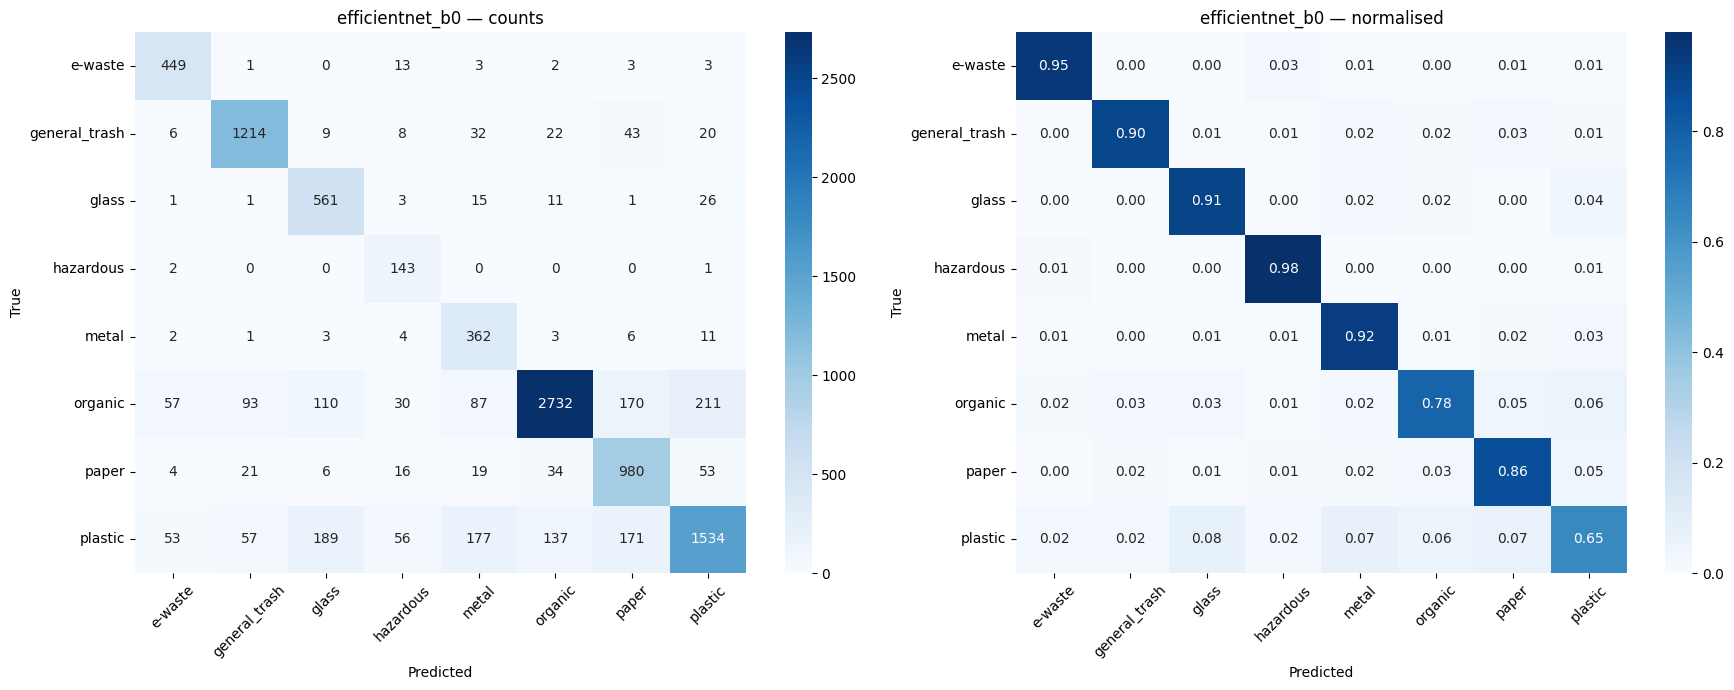

TorchScript model saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_efficientnet_b0/primary_model_scripted.pt
Full checkpoint saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_efficientnet_b0/primary_checkpoint.pth  (16.8 MB)

  ARCHITECTURE: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/prassanna/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|███████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [02:48<00:00, 608kB/s]


Total params  : 24,035,144
Trainable (P1): 527,112

--- Phase 1: feature extraction (base frozen) ---


[resnet50-P1] Epoch 01/10 | train loss 1.4918 acc 0.5910 | val loss 1.8271 acc 0.6817 | 659s *


[resnet50-P1] Epoch 02/10 | train loss 1.4156 acc 0.6295 | val loss 1.7896 acc 0.6990 | 719s *


...

[resnet50-P2] Epoch 16/20 | train loss 0.9586 acc 0.8757 | val loss 1.5505 acc 0.8386 | 853s  


[resnet50-P2] Epoch 17/20 | train loss 0.9479 acc 0.8824 | val loss 1.5372 acc 0.8447 | 856s *


[resnet50-P2] Epoch 18/20 | train loss 0.9430 acc 0.8816 | val loss 1.5113 acc 0.8540 | 838s *


[resnet50-P2] Epoch 19/20 | train loss 0.9334 acc 0.8894 | val loss 1.5235 acc 0.8518 | 843s  


[resnet50-P2] Epoch 20/20 | train loss 0.9305 acc 0.8928 | val loss 1.5154 acc 0.8538 | 848s  

Best val accuracy [resnet50-P2]: 0.8540 (85.40%)


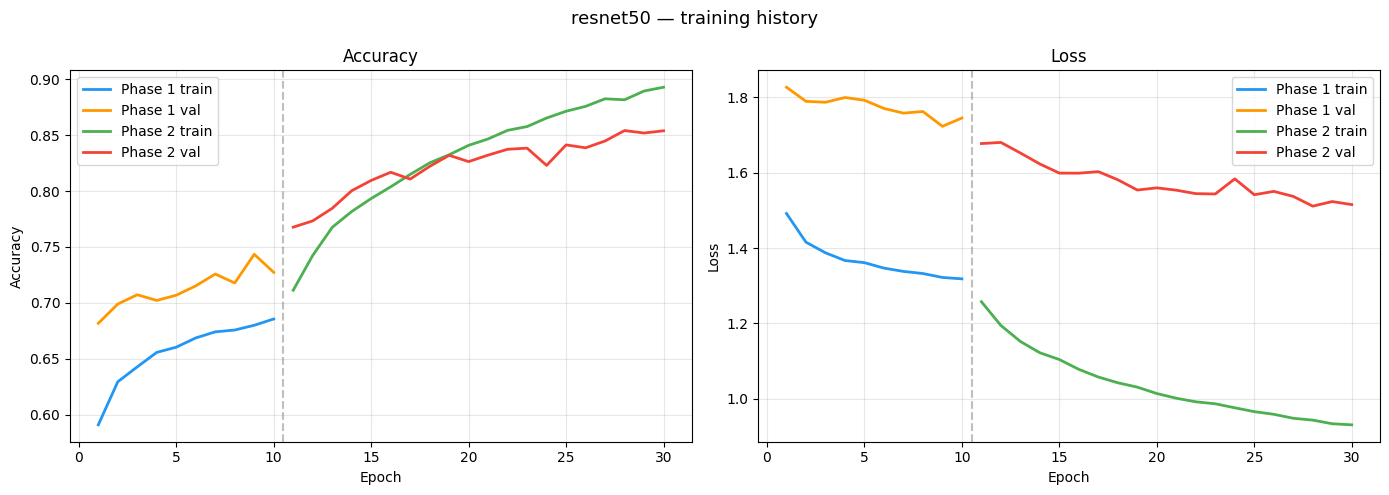

Saved training history plot -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_resnet50/training_history.png


Testing resnet50: 100%|███████████████████████████████████████████████████████████████| 312/312 [01:41<00:00,  3.08it/s]



resnet50 — Test accuracy: 0.8546 | Top-2: 0.9415 | F1(weighted): 0.8555
               precision    recall  f1-score   support

      e-waste     0.8297    0.9662    0.8928       474
general_trash     0.9155    0.9439    0.9295      1354
        glass     0.7371    0.9241    0.8201       619
    hazardous     0.8372    0.9863    0.9057       146
        metal     0.7041    0.9286    0.8009       392
      organic     0.9571    0.7994    0.8712      3490
        paper     0.7951    0.8835    0.8370      1133
      plastic     0.8033    0.8104    0.8069      2374

     accuracy                         0.8546      9982
    macro avg     0.8224    0.9053    0.8580      9982
 weighted avg     0.8651    0.8546    0.8555      9982



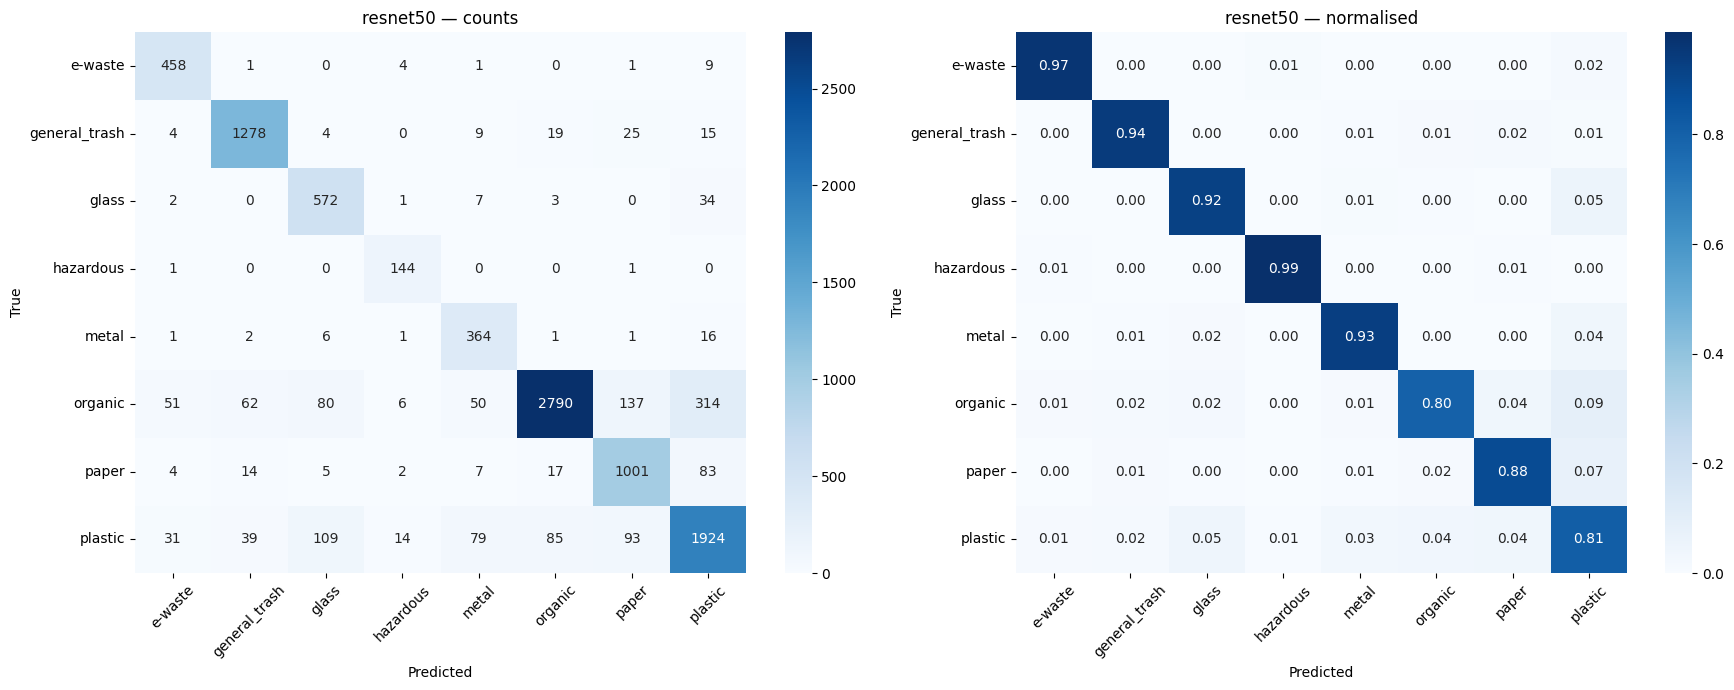

TorchScript model saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_resnet50/primary_model_scripted.pt
Full checkpoint saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_resnet50/primary_checkpoint.pth  (92.0 MB)

  ARCHITECTURE: mobilenet_v2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/prassanna/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:01<00:00, 13.7MB/s]


Total params  : 2,554,376
Trainable (P1): 330,504

--- Phase 1: feature extraction (base frozen) ---


[mobilenet_v2-P1] Epoch 01/10 | train loss 1.5356 acc 0.5641 | val loss 1.9352 acc 0.6162 | 276s *


[mobilenet_v2-P1] Epoch 02/10 | train loss 1.4541 acc 0.6104 | val loss 1.8489 acc 0.6621 | 276s *


...

[mobilenet_v2-P2] Epoch 16/20 | train loss 1.1315 acc 0.7750 | val loss 1.6649 acc 0.7808 | 302s  


[mobilenet_v2-P2] Epoch 17/20 | train loss 1.1306 acc 0.7731 | val loss 1.6489 acc 0.7865 | 299s  


[mobilenet_v2-P2] Epoch 18/20 | train loss 1.1211 acc 0.7797 | val loss 1.6722 acc 0.7701 | 299s  


[mobilenet_v2-P2] Epoch 19/20 | train loss 1.1166 acc 0.7811 | val loss 1.6140 acc 0.8053 | 301s *


[mobilenet_v2-P2] Epoch 20/20 | train loss 1.1112 acc 0.7882 | val loss 1.6332 acc 0.7909 | 301s  

Best val accuracy [mobilenet_v2-P2]: 0.8053 (80.53%)


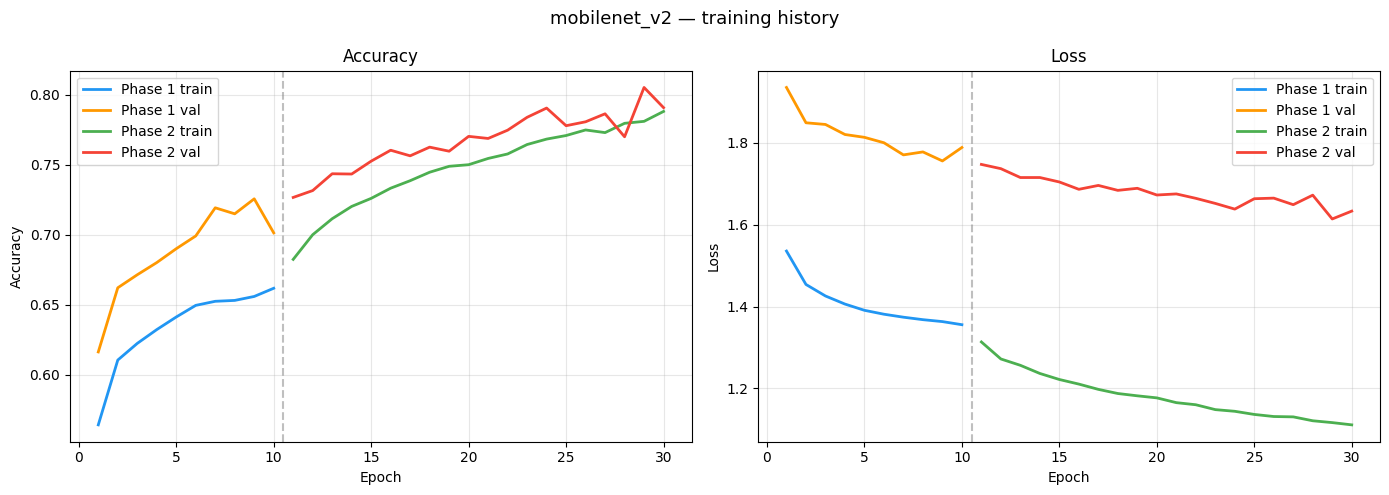

Saved training history plot -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_mobilenet_v2/training_history.png


Testing mobilenet_v2: 100%|███████████████████████████████████████████████████████████| 312/312 [00:33<00:00,  9.35it/s]



mobilenet_v2 — Test accuracy: 0.8071 | Top-2: 0.9266 | F1(weighted): 0.8090
               precision    recall  f1-score   support

      e-waste     0.7177    0.9599    0.8213       474
general_trash     0.8851    0.8936    0.8894      1354
        glass     0.6346    0.9176    0.7503       619
    hazardous     0.6452    0.9589    0.7713       146
        metal     0.5686    0.9413    0.7089       392
      organic     0.9215    0.8003    0.8566      3490
        paper     0.7517    0.8041    0.7770      1133
      plastic     0.8144    0.6782    0.7401      2374

     accuracy                         0.8071      9982
    macro avg     0.7423    0.8692    0.7894      9982
 weighted avg     0.8264    0.8071    0.8090      9982



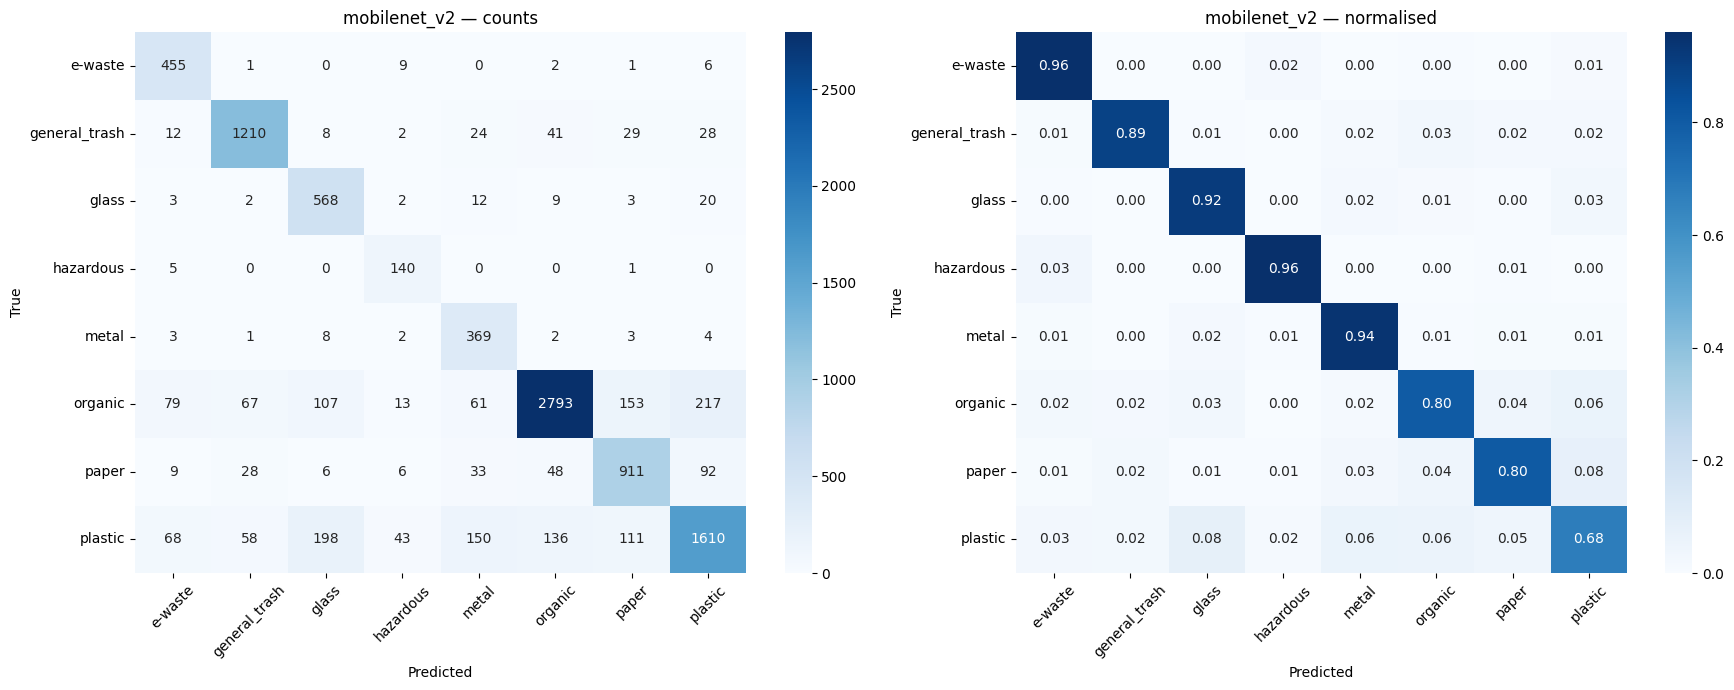

TorchScript model saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_mobilenet_v2/primary_model_scripted.pt
Full checkpoint saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_mobilenet_v2/primary_checkpoint.pth  (10.0 MB)

  ARCHITECTURE: densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/prassanna/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████████████████████████████████████████████████████████████████████████| 30.8M/30.8M [00:04<00:00, 7.92MB/s]


Total params  : 7,218,824
Trainable (P1): 264,968

--- Phase 1: feature extraction (base frozen) ---


[densenet121-P1] Epoch 01/10 | train loss 1.5712 acc 0.5456 | val loss 1.8383 acc 0.6724 | 681s *


[densenet121-P1] Epoch 02/10 | train loss 1.4866 acc 0.5867 | val loss 1.8044 acc 0.6950 | 683s *


...

[densenet121-P2] Epoch 16/20 | train loss 1.2632 acc 0.7049 | val loss 1.6994 acc 0.7537 | 793s  


[densenet121-P2] Epoch 17/20 | train loss 1.2572 acc 0.7056 | val loss 1.6929 acc 0.7588 | 791s *


[densenet121-P2] Epoch 18/20 | train loss 1.2567 acc 0.7078 | val loss 1.6874 acc 0.7604 | 800s *


[densenet121-P2] Epoch 19/20 | train loss 1.2494 acc 0.7095 | val loss 1.6863 acc 0.7629 | 773s *


[densenet121-P2] Epoch 20/20 | train loss 1.2501 acc 0.7102 | val loss 1.6714 acc 0.7716 | 713s *

Best val accuracy [densenet121-P2]: 0.7716 (77.16%)


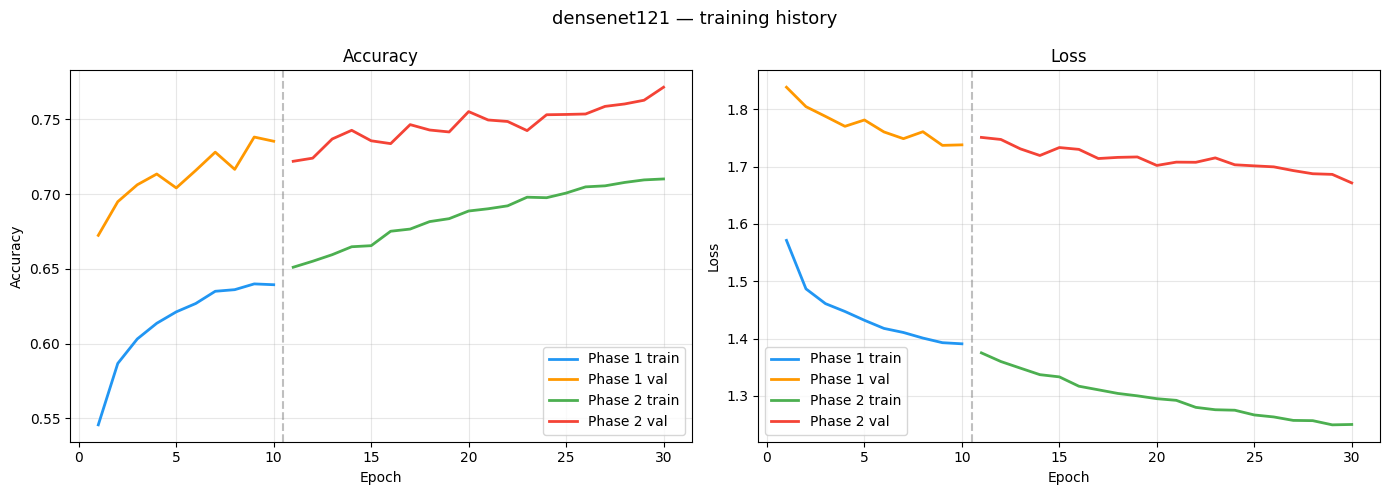

Saved training history plot -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_densenet121/training_history.png


Testing densenet121: 100%|████████████████████████████████████████████████████████████| 312/312 [01:43<00:00,  3.02it/s]



densenet121 — Test accuracy: 0.7688 | Top-2: 0.9034 | F1(weighted): 0.7740
               precision    recall  f1-score   support

      e-waste     0.6568    0.9409    0.7736       474
general_trash     0.8462    0.8936    0.8693      1354
        glass     0.6671    0.8481    0.7468       619
    hazardous     0.4172    0.9658    0.5826       146
        metal     0.4724    0.9184    0.6239       392
      organic     0.9440    0.7344    0.8261      3490
        paper     0.6950    0.8085    0.7475      1133
      plastic     0.7747    0.6373    0.6993      2374

     accuracy                         0.7688      9982
    macro avg     0.6842    0.8434    0.7336      9982
 weighted avg     0.8052    0.7688    0.7740      9982



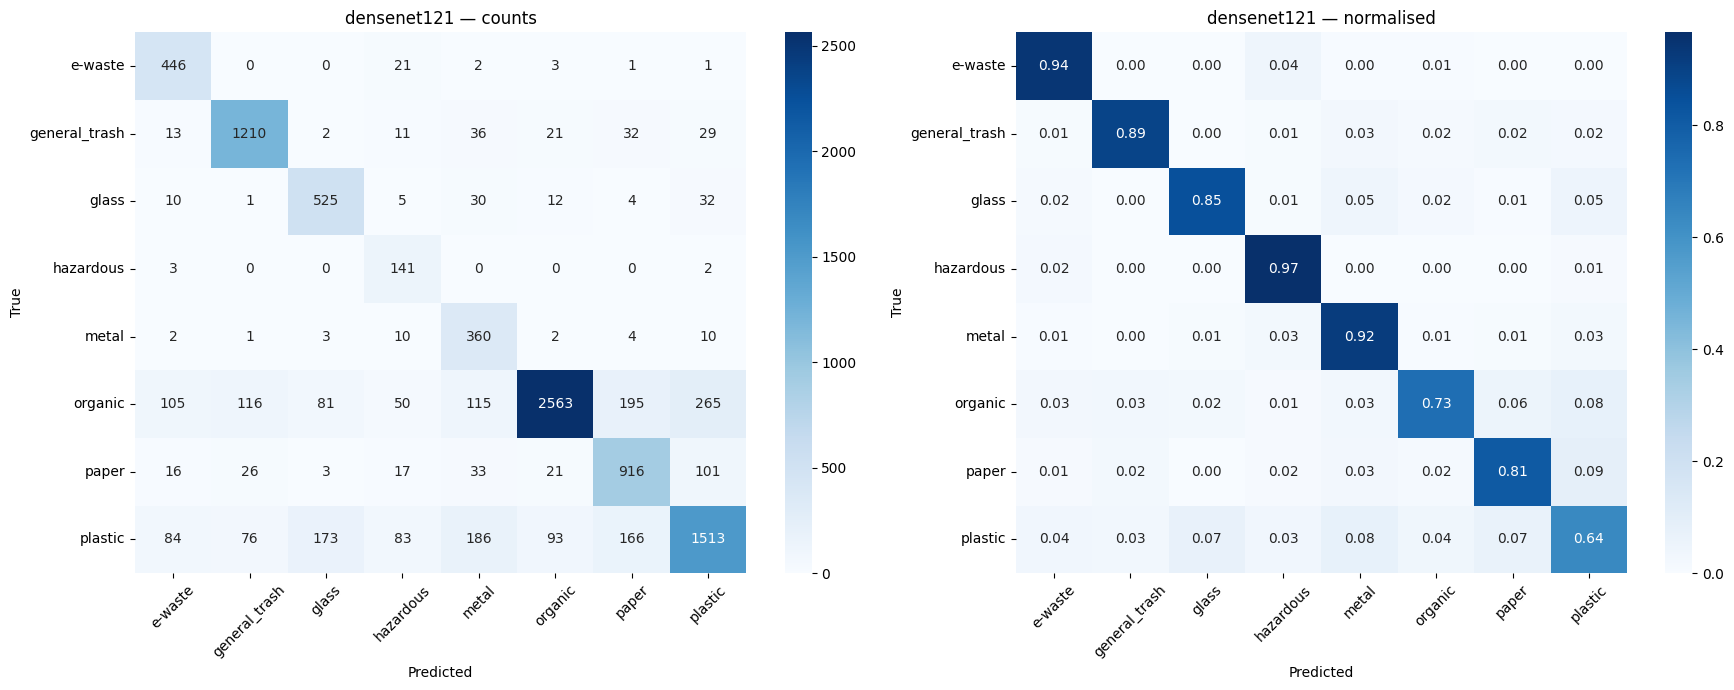

TorchScript model saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_densenet121/primary_model_scripted.pt
Full checkpoint saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_densenet121/primary_checkpoint.pth  (28.1 MB)

  ALL 4 ARCHITECTURES TRAINED


In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import json as _json

all_histories = {}     # arch -> {'phase1': hist, 'phase2': hist}
all_test_results = {}  # arch -> dict of metrics + raw preds
all_models = {}         # arch -> trained model object (kept for inference cell)

for arch in ARCHITECTURES:
    MODELS_DIR = MODEL_DIRS[arch]
    print('\n' + '=' * 65)
    print(f'  ARCHITECTURE: {arch}')
    print('=' * 65)

    model, backbone, head = build_model(arch, NUM_CLASSES, DROPOUT_RATE)
    model = model.to(DEVICE)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total params  : {total_params:,}')
    print(f'Trainable (P1): {trainable_params:,}')

    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS_TENSOR,
        label_smoothing=LABEL_SMOOTHING
    )

    # ── PHASE 1 — frozen backbone ────────────────────────────────────────────
    optimizer_p1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR_PHASE1
    )
    scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p1, mode='min', factor=0.5, patience=3
    )
    phase1_save = str(MODELS_DIR / 'primary_phase1_best.pth')

    print(f'\n--- Phase 1: feature extraction (base frozen) ---')
    history_p1, _ = run_training(
        model, train_loader, val_loader, criterion, optimizer_p1, scheduler_p1,
        epochs=EPOCHS_PHASE1, device=DEVICE, save_path=phase1_save, phase_name=f'{arch}-P1'
    )

    # ── PHASE 2 — partial unfreeze fine-tune ─────────────────────────────────
    backbone_params = list(backbone.parameters())
    total_backbone_params = len(backbone_params)
    unfreeze_from = max(0, total_backbone_params - UNFREEZE_LAYERS)
    for i, param in enumerate(backbone_params):
        param.requires_grad = (i >= unfreeze_from)
    for param in head.parameters():
        param.requires_grad = True

    trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\nUnfroze last {UNFREEZE_LAYERS} backbone parameter tensors.')
    print(f'Trainable params now: {trainable_now:,}')

    optimizer_p2 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR_PHASE2
    )
    scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p2, mode='min', factor=0.5, patience=4
    )
    phase2_save = str(MODELS_DIR / 'primary_best.pth')

    print(f'\n--- Phase 2: fine-tuning (top layers unfrozen) ---')
    history_p2, best_val_acc = run_training(
        model, train_loader, val_loader, criterion, optimizer_p2, scheduler_p2,
        epochs=EPOCHS_PHASE2, device=DEVICE, save_path=phase2_save, phase_name=f'{arch}-P2'
    )

    all_histories[arch] = {'phase1': history_p1, 'phase2': history_p2}

    plot_history(
        [history_p1, history_p2], ['Phase 1', 'Phase 2'],
        save_path=MODELS_DIR / 'training_history.png',
        title=f'{arch} — training history'
    )

    # ── TEST EVALUATION ───────────────────────────────────────────────────────
    model.load_state_dict(torch.load(phase2_save, map_location=DEVICE))
    model.eval()

    all_preds, all_labels_test, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {arch}'):
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_test.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels_test = np.array(all_labels_test)
    all_probs = np.array(all_probs)

    test_acc = (all_preds == all_labels_test).mean()
    top2_acc = sum(
        true in np.argsort(probs_row)[-2:]
        for true, probs_row in zip(all_labels_test, all_probs)
    ) / len(all_labels_test)
    f1_weighted = f1_score(all_labels_test, all_preds, average='weighted')
    f1_macro    = f1_score(all_labels_test, all_preds, average='macro')
    per_class_f1 = f1_score(all_labels_test, all_preds, average=None)

    report = classification_report(all_labels_test, all_preds, target_names=CLASS_NAMES, digits=4)
    print(f'\n{arch} — Test accuracy: {test_acc:.4f} | Top-2: {top2_acc:.4f} | F1(weighted): {f1_weighted:.4f}')
    print(report)

    with open(MODELS_DIR / 'classification_report.txt', 'w') as f:
        f.write(f'Test accuracy : {test_acc:.4f}\n')
        f.write(f'Top-2 accuracy: {top2_acc:.4f}\n')
        f.write(f'F1 (weighted) : {f1_weighted:.4f}\n\n')
        f.write(report)

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(all_labels_test, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, title in zip(
        axes, [cm, cm_norm], ['d', '.2f'],
        [f'{arch} — counts', f'{arch} — normalised']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                   xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
        ax.set_title(title); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ── Save checkpoint (same format as original notebook) ───────────────────
    model.to('cpu')
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    try:
        traced_model = torch.jit.trace(model, dummy_input)
        ts_path = str(MODELS_DIR / 'primary_model_scripted.pt')
        traced_model.save(ts_path)
        print(f'TorchScript model saved -> {ts_path}')
    except Exception as e:
        print(f'  ⚠  TorchScript trace failed for {arch} ({e}) — skipping .pt export, .pth still saved.')

    checkpoint = {
        'model_state_dict' : model.state_dict(),
        'arch_name'        : arch,
        'class_to_idx'     : CLASS_TO_IDX,
        'idx_to_class'     : IDX_TO_CLASS,
        'class_names'      : CLASS_NAMES,
        'num_classes'      : NUM_CLASSES,
        'img_size'         : IMG_SIZE,
        'test_accuracy'    : float(test_acc),
        'f1_weighted'      : float(f1_weighted),
        'imagenet_mean'    : IMAGENET_MEAN,
        'imagenet_std'     : IMAGENET_STD,
    }
    ckpt_path = str(MODELS_DIR / 'primary_checkpoint.pth')
    torch.save(checkpoint, ckpt_path)
    size_mb = os.path.getsize(ckpt_path) / (1024 * 1024)
    print(f'Full checkpoint saved -> {ckpt_path}  ({size_mb:.1f} MB)')
    model.to(DEVICE)

    all_test_results[arch] = {
        'test_accuracy': float(test_acc),
        'top2_accuracy': float(top2_acc),
        'f1_weighted': float(f1_weighted),
        'f1_macro': float(f1_macro),
        'per_class_f1': {CLASS_NAMES[i]: float(per_class_f1[i]) for i in range(NUM_CLASSES)},
        'best_val_acc': float(best_val_acc),
        'total_params': int(total_params),
        'checkpoint_size_mb': float(size_mb),
        'checkpoint_path': ckpt_path,
        'labels': all_labels_test.tolist(),
        'preds': all_preds.tolist(),
    }
    all_models[arch] = model

print('\n' + '=' * 65)
print('  ALL 4 ARCHITECTURES TRAINED')
print('=' * 65)


## Cell 8 — Comparison table across all 4 architectures

In [8]:
import pandas as pd

rows = []
for arch, r in all_test_results.items():
    rows.append({
        'Model': arch,
        'Test Acc': round(r['test_accuracy'], 4),
        'Top-2 Acc': round(r['top2_accuracy'], 4),
        'F1 (weighted)': round(r['f1_weighted'], 4),
        'F1 (macro)': round(r['f1_macro'], 4),
        'Params (M)': round(r['total_params'] / 1e6, 2),
        'Checkpoint (MB)': round(r['checkpoint_size_mb'], 1),
    })

comparison_df = pd.DataFrame(rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
print('\nMODEL COMPARISON TABLE\n')
print(comparison_df.to_string(index=False))

comparison_csv = COMPARISON_DIR / 'comparison_table.csv'
comparison_df.to_csv(comparison_csv, index=False)
print(f'\nSaved -> {comparison_csv}')

BEST_ARCH = comparison_df.iloc[0]['Model']
print(f'\nBest architecture by test accuracy: {BEST_ARCH}')



MODEL COMPARISON TABLE

          Model  Test Acc  Top-2 Acc  F1 (weighted)  F1 (macro)  Params (M)  Checkpoint (MB)
       resnet50    0.8546     0.9415         0.8555      0.8580       24.04             92.0
   mobilenet_v2    0.8071     0.9266         0.8090      0.7894        2.55             10.0
efficientnet_b0    0.7989     0.9153         0.8016      0.7746        4.34             16.8
    densenet121    0.7688     0.9034         0.7740      0.7336        7.22             28.1

Saved -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison_4arch/comparison_table.csv

Best architecture by test accuracy: resnet50


## Cell 9 — Comparison charts

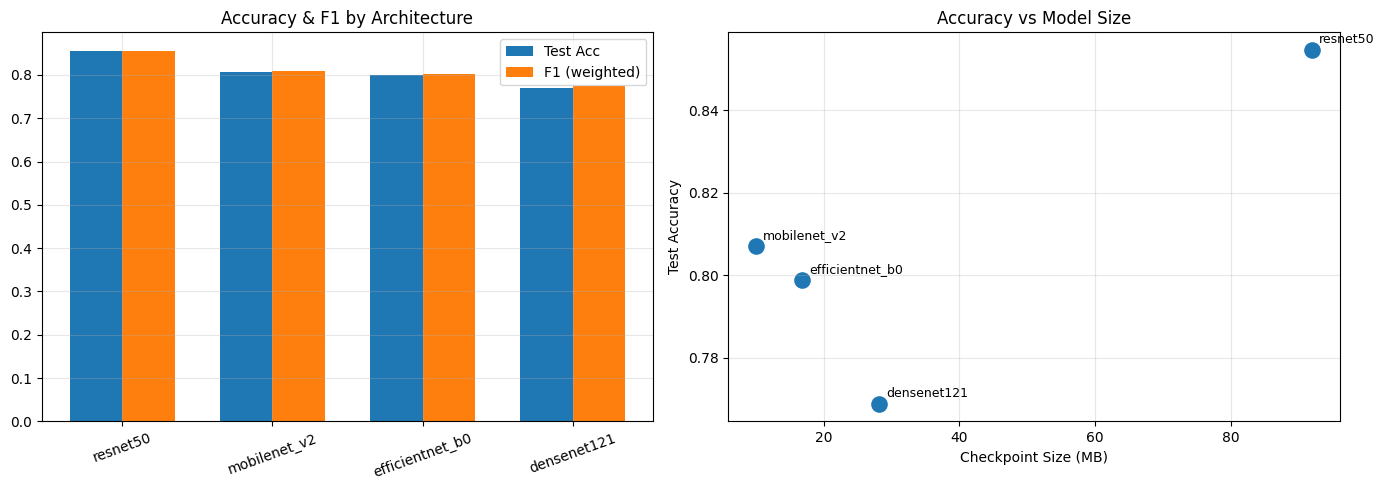

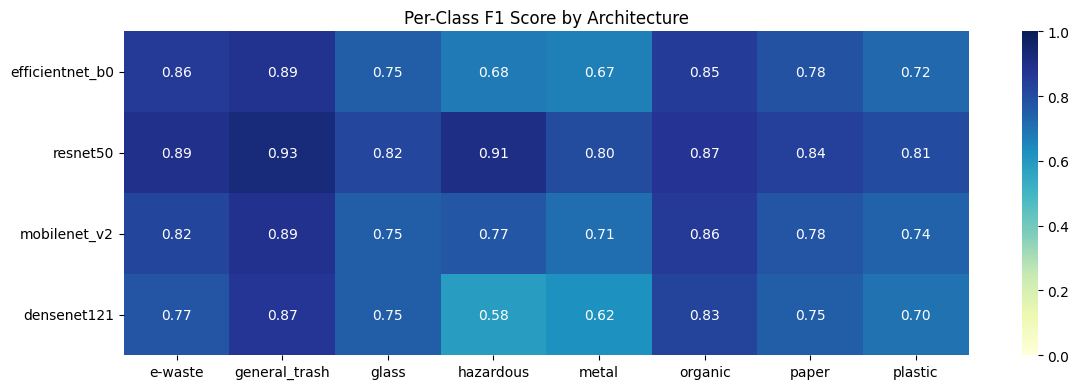

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison_df))
w = 0.35
axes[0].bar(x - w/2, comparison_df['Test Acc'], w, label='Test Acc')
axes[0].bar(x + w/2, comparison_df['F1 (weighted)'], w, label='F1 (weighted)')
axes[0].set_xticks(x); axes[0].set_xticklabels(comparison_df['Model'], rotation=20)
axes[0].set_title('Accuracy & F1 by Architecture'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(comparison_df['Checkpoint (MB)'], comparison_df['Test Acc'], s=120)
for _, row in comparison_df.iterrows():
    axes[1].annotate(row['Model'], (row['Checkpoint (MB)'], row['Test Acc']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[1].set_xlabel('Checkpoint Size (MB)'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Accuracy vs Model Size'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(COMPARISON_DIR / 'architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 heatmap ──────────────────────────────────────────────────────
per_class_matrix = pd.DataFrame({arch: all_test_results[arch]['per_class_f1'] for arch in ARCHITECTURES}).T
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(per_class_matrix, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=ax)
ax.set_title('Per-Class F1 Score by Architecture')
plt.tight_layout()
plt.savefig(COMPARISON_DIR / 'per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 10 — Final summary

In [10]:
summary = {
    'dataset': str(DATASET_PATH),
    'device': str(DEVICE),
    'comparison_table': comparison_df.to_dict(orient='records'),
    'best_architecture': BEST_ARCH,
    'per_class_f1_by_architecture': per_class_matrix.round(4).to_dict(orient='index'),
    'model_paths': {arch: all_test_results[arch]['checkpoint_path'] for arch in ARCHITECTURES},
}
summary_path = COMPARISON_DIR / 'full_summary.json'
with open(summary_path, 'w') as f:
    _json.dump(summary, f, indent=2)

print('=' * 65)
print('  Group 51 — 4-Architecture Training Complete')
print('=' * 65)
for _, row in comparison_df.iterrows():
    print(f"  {row['Model']:<18} Acc: {row['Test Acc']:.4f}  F1: {row['F1 (weighted)']:.4f}  "
          f"Size: {row['Checkpoint (MB)']:.1f}MB")
print(f'\nBest architecture: {BEST_ARCH}')
print(f'\nModel folders created:')
for arch, d in MODEL_DIRS.items():
    print(f'  model_{arch}/  -> {d}')
print(f'\nComparison outputs: {COMPARISON_DIR}')
print(f'Summary JSON: {summary_path}')


  Group 51 — 4-Architecture Training Complete
  resnet50           Acc: 0.8546  F1: 0.8555  Size: 92.0MB
  mobilenet_v2       Acc: 0.8071  F1: 0.8090  Size: 10.0MB
  efficientnet_b0    Acc: 0.7989  F1: 0.8016  Size: 16.8MB
  densenet121        Acc: 0.7688  F1: 0.7740  Size: 28.1MB

Best architecture: resnet50

Model folders created:
  model_efficientnet_b0/  -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_efficientnet_b0
  model_resnet50/  -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_resnet50
  model_mobilenet_v2/  -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_mobilenet_v2
  model_densenet121/  -> /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/model_densenet121

Comparison outputs: /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison_4arch
Summary JSON: /Users/prassanna/Downloads/Capstone_project/model_and_data_pipeline/comparison_4arch/full_summary